In [ ]:
# ----------------------------------------------------------------------
# Setup cell: install all third-party packages and import everything
# the rest of the notebook needs. We keep all imports here so the other
# cells stay focused on the actual analysis logic.
# ----------------------------------------------------------------------
%pip install ipykernel pandas numpy scipy scikit-learn matplotlib seaborn wordcloud gensim vaderSentiment nltk

# --- Core data handling ---
import re               # Regex — used by the lyrics tokenizer below
import pandas as pd     # DataFrames: tabular data, merging, grouping, IO
import numpy as np      # Vectorized math, arrays for ML feature matrices
from scipy import stats # Statistical tests (Welch t-test for the sentiment hypothesis)

# --- IO / NLP utilities ---
import tarfile      # Reading the compressed lyrics archive (processed_lyrics.tar.gz) without extracting it to disk
import gensim       # NLP toolkit (we use it for Word2Vec text embeddings)
import nltk         # Natural Language Toolkit (gives us a curated stopword list)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer  # Lexicon-based sentiment scorer (positive/negative/neutral/compound)

# Download the English stopword list once (quiet=True suppresses the
# progress bar). Stopwords are very common words ("the", "is", "and", ...)
# that carry little semantic meaning and are usually filtered out before
# text analysis to avoid biasing word-frequency results.
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOP_WORDS = set(stopwords.words('english'))  # set → O(1) membership checks

# --- Machine Learning tools (all from scikit-learn) ---
from sklearn.cluster import KMeans                       # Unsupervised clustering (used in Part B)
from sklearn.preprocessing import StandardScaler         # Z-score normalization — REQUIRED before PCA on heterogeneous features
from sklearn.decomposition import PCA                    # Linear dimensionality reduction; used to compress MFCC features
from sklearn.manifold import TSNE                        # Non-linear 2D projection for visualizing high-dim embeddings
from sklearn.metrics.pairwise import cosine_similarity   # Angle-based similarity between two vectors (1 = identical direction)

# --- Plotting / visualization ---
import matplotlib.pyplot as plt     # Low-level plotting API
import seaborn as sns               # Higher-level statistical plots (nicer defaults on top of matplotlib)
from wordcloud import WordCloud     # Generates a wordcloud image where word size ∝ frequency

# Global random seed for reproducibility of any np-based sampling below.
np.random.seed(42)


Note: you may need to restart the kernel to use updated packages.


# Εξόρυξη Γνώσης από Μουσικά Δεδομένα (Audio & Lyrics)

**Ομάδα:**
* Παναγιώτης Μακαρόνας (AM: sdi2300107)
* Αχιλλέας Νιανιακούδης-Κοέν (AM: sdi2300138)

## 1. Συλλογή Δεδομένων (Data collection)
Σε αυτό το κελί φορτώνονται τα δεδομένα, εφαρμόζεται το φιλτράρισμα στα Top-5 Genres και πραγματοποιείται το intersection των αρχείων.

In [ ]:
# =====================================================================
# PART 1 — DATA COLLECTION
# Goal: load all 5 source files, keep only songs that appear in every
# modality (genre + audio MFCCs + lyrics), restrict to the Top-5 most
# frequent genres, and produce a single balanced DataFrame `df`.
# =====================================================================

# --- File paths (all 5 input files from eClass) ---
genres_path = "data/id_genres.csv"             # song_id -> comma-separated list of genres
info_path = "data/id_information.csv"          # song_id -> artist/title/etc. (metadata)
mfcc_path = "data/id_mfcc_stats.tsv.bz2"       # song_id -> ~100+ MFCC statistical features (audio fingerprint)
tags_path = "data/id_tags.csv"                 # song_id -> user-assigned tags (free-text labels)
lyrics_archive = "data/processed_lyrics.tar.gz"  # tar.gz containing one .txt of preprocessed lyrics per song

# --- Load the small TSV files directly into DataFrames ---
# All three files use TAB as the separator (despite the .csv extension).
df_genres = pd.read_csv(genres_path, sep='\t')
df_info = pd.read_csv(info_path, sep='\t')
df_tags = pd.read_csv(tags_path, sep='\t')

# --- Load the large MFCC file in chunks ---
# The file is bz2-compressed and has many rows; reading it in 2000-row
# chunks keeps peak memory usage low. We then concat once at the end.
mfcc_chunks = []
for chunk in pd.read_csv(mfcc_path, sep='\t', compression='bz2', chunksize=2000):
    mfcc_chunks.append(chunk)
df_mfcc = pd.concat(mfcc_chunks, ignore_index=True)

# Different files may name the song-id column differently. Force it to
# 'id' so every later merge is unambiguous.
mfcc_id_col = df_mfcc.columns[0]
if mfcc_id_col != 'id':
    df_mfcc = df_mfcc.rename(columns={mfcc_id_col: 'id'})

# Defensive: if MFCC happens to ship its own 'genre' column, drop it now
# to avoid silent column collisions during the later merge with df.
if 'genre' in df_mfcc.columns:
    df_mfcc = df_mfcc.drop(columns=['genre'])

# --- Normalize the genre column ---
# Each row in id_genres.csv looks like "rock,alternative,indie".
# We split on commas and explode so each (song, genre) pair becomes a
# separate row — easier to filter and count than nested lists.
df_genres['genre'] = df_genres['genres'].str.split(',')
df_genres = df_genres.explode('genre')
df_genres['genre'] = df_genres['genre'].str.strip()  # drop accidental whitespace

# --- Keep only the Top-5 most frequent genres (assignment requirement) ---
top5 = df_genres['genre'].value_counts().head(5).index.tolist()
df_genres = df_genres[df_genres['genre'].isin(top5)]
print(f"Top-5 genres: {top5}")

# Each song still has multiple rows (one per genre it belongs to).
# We need exactly one genre per song for supervised classification later,
# so we deterministically pick the first match (the order from the file).
df_genres = df_genres.drop_duplicates(subset='id', keep='first')

# Build an explicit (id -> genre) dictionary. We keep this around so we
# can ALWAYS re-attach the correct genre after merges, even if pandas
# accidentally renames or drops the column.
genre_map = dict(zip(df_genres['id'].astype(str), df_genres['genre']))

# --- Compute the intersection of all modalities ---
# A song is only useful to us if it has a genre AND audio AND lyrics.
genre_ids = set(df_genres['id'].astype(str))
mfcc_ids = set(df_mfcc['id'].astype(str))
common_ids = genre_ids & mfcc_ids   # set intersection (∩)

# --- Stream the lyrics out of the tar.gz, but only for songs we need ---
# This avoids extracting tens of thousands of irrelevant .txt files.
lyrics_dict = {}
with tarfile.open(lyrics_archive, 'r:gz') as tar:
    for member in tar:
        if not member.isfile():
            continue
        # Filenames look like "processed_lyrics/<song_id>.txt"
        song_id = member.name.split('/')[-1].replace('.txt', '')
        if song_id in common_ids:
            f = tar.extractfile(member)
            if f:
                # errors='ignore' = drop a few non-UTF8 bytes silently
                lyrics_dict[song_id] = f.read().decode('utf-8', errors='ignore')

df_lyrics = pd.DataFrame(list(lyrics_dict.items()), columns=['id', 'lyrics'])
# Final intersection now includes the lyrics constraint too.
final_ids = common_ids & set(df_lyrics['id'])

# --- Build the final DataFrame from a known-good base ---
# Starting from df_lyrics (which definitely has 'id' and 'lyrics') and
# attaching genre via our trusted map guarantees the schema is correct.
df = df_lyrics[df_lyrics['id'].isin(final_ids)].copy()
df['id'] = df['id'].astype(str)
df['genre'] = df['id'].map(genre_map)

# Attach all MFCC audio features. suffixes=('', '_mfcc') means: if there
# is a column-name collision, the MFCC version gets the suffix, never
# silently overwriting columns we already trust (id, genre, lyrics).
df_mfcc['id'] = df_mfcc['id'].astype(str)
df = df.merge(df_mfcc, on='id', how='left', suffixes=('', '_mfcc'))

# Re-assert genre from our mapping after the merge. This is paranoia
# against pandas/file-version quirks that occasionally clobbered the
# column during development.
df['genre'] = df['id'].map(genre_map)

# Sanity checks — fail fast if something silently went wrong.
assert 'genre' in df.columns, "'genre' column missing after merges!"
assert df['genre'].isna().sum() == 0, "Some songs have no genre after merges!"

# --- Balanced sampling: take up to N songs per genre ---
# This prevents the most populous genre from dominating later models.
SAMPLE_PER_GENRE = 2000
df_sampled = []
for g in df['genre'].unique():
    genre_df = df[df['genre'] == g]
    # min(...) handles genres with fewer than 2000 available songs.
    # random_state=42 makes the sample reproducible across runs.
    sampled = genre_df.sample(min(len(genre_df), SAMPLE_PER_GENRE), random_state=42)
    df_sampled.append(sampled)
df = pd.concat(df_sampled, ignore_index=True)

# --- Quick report so we can eyeball the result ---
print(f"\nFinal dataset: {len(df)} songs across {df['genre'].nunique()} genres")
print(df['genre'].value_counts())
print(df[['id', 'genre', 'lyrics']].head())


Top-5 genres: ['rock', 'pop', 'electronic', 'alternative rock', 'indie rock']

Final dataset: 10000 songs across 5 genres
genre
rock                2000
alternative rock    2000
pop                 2000
indie rock          2000
electronic          2000
Name: count, dtype: int64
                 id genre                                             lyrics
0  uORMwZEydnnPWCf3  rock  move talk time think worri everyth fine fine g...
1  tF4fFZp2rIPnr2T7  rock  larri call load smoke want lose coupl day prob...
2  yKqVJ4TBJzPDJABc  rock  light green green dark green brown everi life ...
3  NwbcLd9ls0zUSu8E  rock  east mode everybodi strike pose everybodi tax ...
4  zGdLJNjLygap1tYJ  rock  say exist help say exist protect know stop kno...


## 2. Εξαγωγή Χαρακτηριστικών & Embeddings (Feature Extraction)
Εδώ δημιουργούνται οι διανυσματικές αναπαραστάσεις για το κείμενο (Word2Vec, με average-pooling των word vectors ανά τραγούδι) και για τον ήχο (StandardScaler + PCA στα MFCCs ώστε όλα τα features να έχουν την ίδια κλίμακα πριν την μείωση διαστάσεων).


In [ ]:
# =====================================================================
# PART 2 — FEATURE EXTRACTION / EMBEDDINGS
# Goal: turn each song into TWO fixed-length numerical vectors
#   (a) text embedding from its lyrics  (semantic content)
#   (b) audio embedding from its MFCCs  (acoustic content)
# Both are needed for the comparisons in Part 3.
# =====================================================================

# --- (a) TEXT EMBEDDINGS via Word2Vec ---
from gensim.models import Word2Vec

# Tokenizer: lowercase, then keep only alphanumeric/apostrophe runs.
# A naive `lower().split()` glues punctuation onto words ("love," ≠ "love"),
# which inflates the vocabulary and degrades the learned word vectors.
_TOKEN_RE = re.compile(r"[a-z0-9']+")
def tokenize(text):
    return _TOKEN_RE.findall(text.lower())

tokenized = df['lyrics'].apply(tokenize).tolist()

# Train a Word2Vec model from scratch on the lyrics corpus.
#   vector_size=128 : each word becomes a 128-dim vector
#   window=5        : context window: ±5 words around the target word
#   min_count=2     : ignore rare words (appearing < 2 times) to cut noise
#   workers=1, seed=42 : fully deterministic training (reproducible across
#                        runs at the cost of some speed; corpus is small
#                        enough that this is fine).
#   epochs=10       : number of full passes over the corpus
w2v_model = Word2Vec(sentences=tokenized, vector_size=128,
                     window=5, min_count=2, workers=1, seed=42, epochs=10)
print(f"Word2Vec vocabulary size: {len(w2v_model.wv)}")

def song_text_embedding(words, model):
    """Average-pool word vectors to get one fixed-length vector per song.

    Word2Vec gives us a vector PER WORD. To represent a whole song, we
    average all its word vectors — a simple but effective baseline that
    captures the song's overall semantic 'direction'. Words not in the
    trained vocabulary are skipped. Empty/all-OOV songs get a zero vector.
    """
    vecs = [model.wv[w] for w in words if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

# Stack one 128-d vector per song into a (n_songs, 128) matrix.
text_embeddings = np.vstack(
    [song_text_embedding(tok, w2v_model) for tok in tokenized]
)
print(f"Text embeddings shape: {text_embeddings.shape}")

# --- (b) AUDIO EMBEDDINGS via StandardScaler + PCA on MFCC statistics ---
# Pick all the MFCC columns: every column that is NOT one of our
# bookkeeping/text columns is an MFCC feature.
mfcc_cols = [c for c in df.columns if c not in ['id', 'genre', 'lyrics', 'genres']]
mfcc_matrix = df[mfcc_cols].values.astype(np.float32)

# PCA cannot handle NaN/Inf — replace any with 0. (A few MFCC stats can
# be undefined for very short or silent tracks.)
mfcc_matrix = np.nan_to_num(mfcc_matrix, nan=0.0, posinf=0.0, neginf=0.0)

# CRITICAL: standardize before PCA. MFCC statistics (means, variances,
# deltas, ...) live on very different scales; without z-scoring, PCA's
# variance-maximization is dominated by whichever feature happens to
# have the largest absolute range and the resulting components mostly
# encode that single feature instead of real audio structure.
scaler = StandardScaler()
mfcc_scaled = scaler.fit_transform(mfcc_matrix)

# PCA reduces dimensionality while preserving variance.
# n_components=0.95 → keep enough components to explain 95% of total
# variance. This drops mostly-redundant dimensions (cheaper similarity
# computation, less noise) without losing much real information.
pca = PCA(n_components=0.95, random_state=42)
audio_embeddings = pca.fit_transform(mfcc_scaled)
print(f"Audio PCA: {mfcc_matrix.shape[1]} dims → {audio_embeddings.shape[1]} dims "
      f"({pca.n_components_} components, 95% variance)")

# Store both embeddings back into the DataFrame as object columns
# (each cell holds a numpy array). Convenient for per-row access later.
df['text_emb'] = list(text_embeddings)
df['audio_emb'] = list(audio_embeddings)
print("Embeddings stored in DataFrame")


Word2Vec vocabulary size: 12414
Text embeddings shape: (10000, 128)
Audio PCA: 104 dims → 57 dims (57 components, 95% variance)
Embeddings stored in DataFrame


/tmp/ipykernel_116804/3089234678.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['text_emb'] = list(text_embeddings)
/tmp/ipykernel_116804/3089234678.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['audio_emb'] = list(audio_embeddings)


## 3. Οπτικοποίηση και Ανάλυση (Exploratory Data Analysis - EDA)
Ανάλυση των tags, word clouds, 2D projections (PCA/t-SNE) και Cosine Similarity.

Word clouds for: 'electronic' vs 'rock'


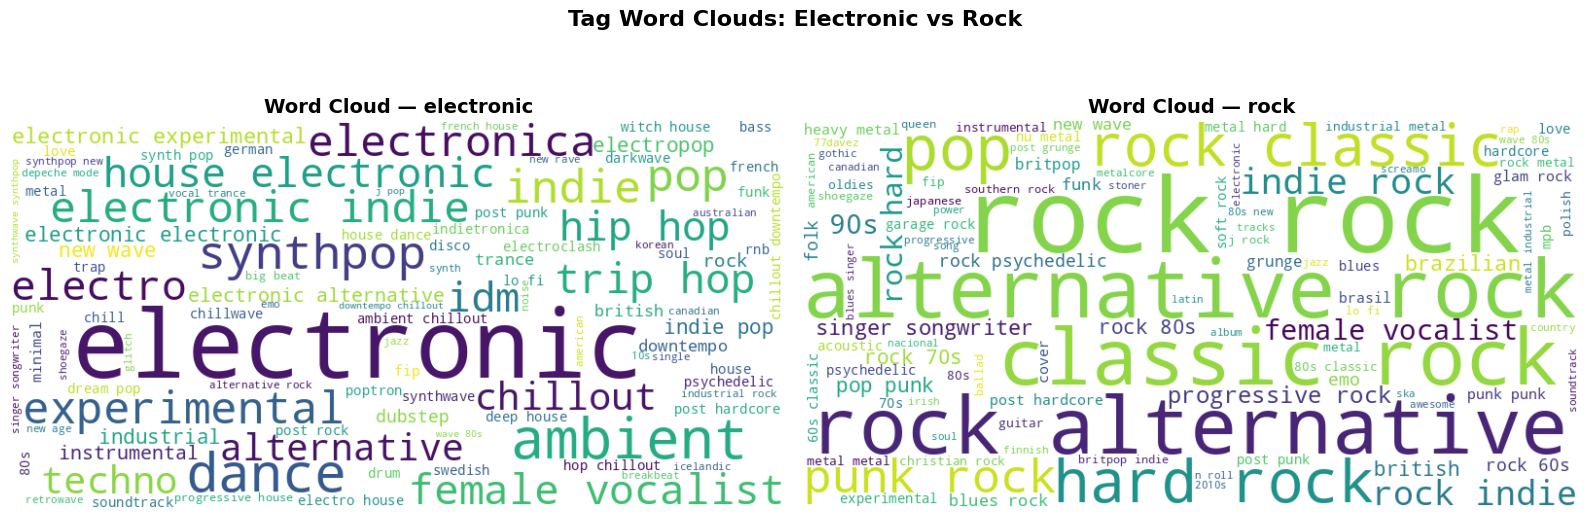

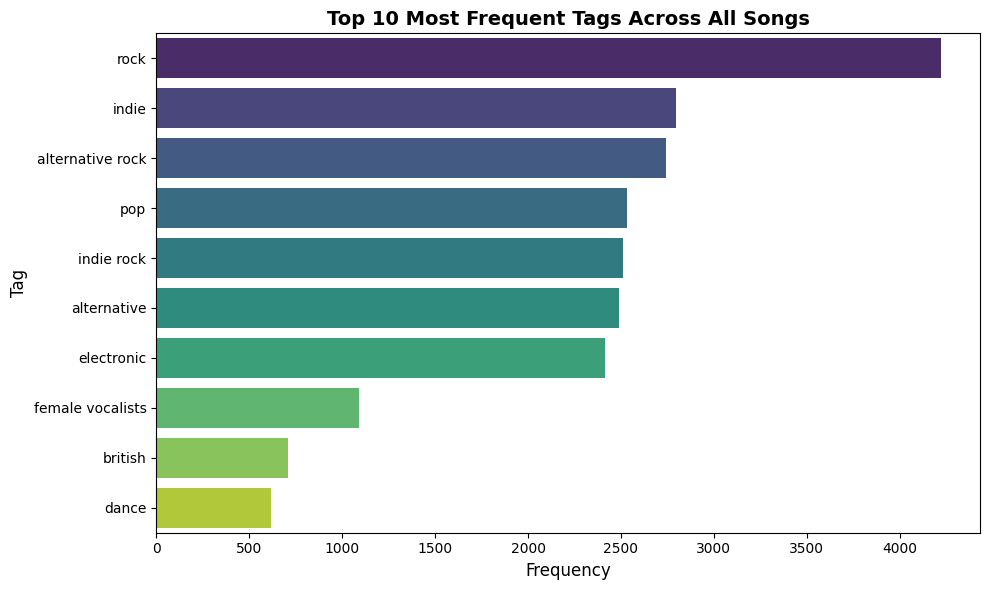

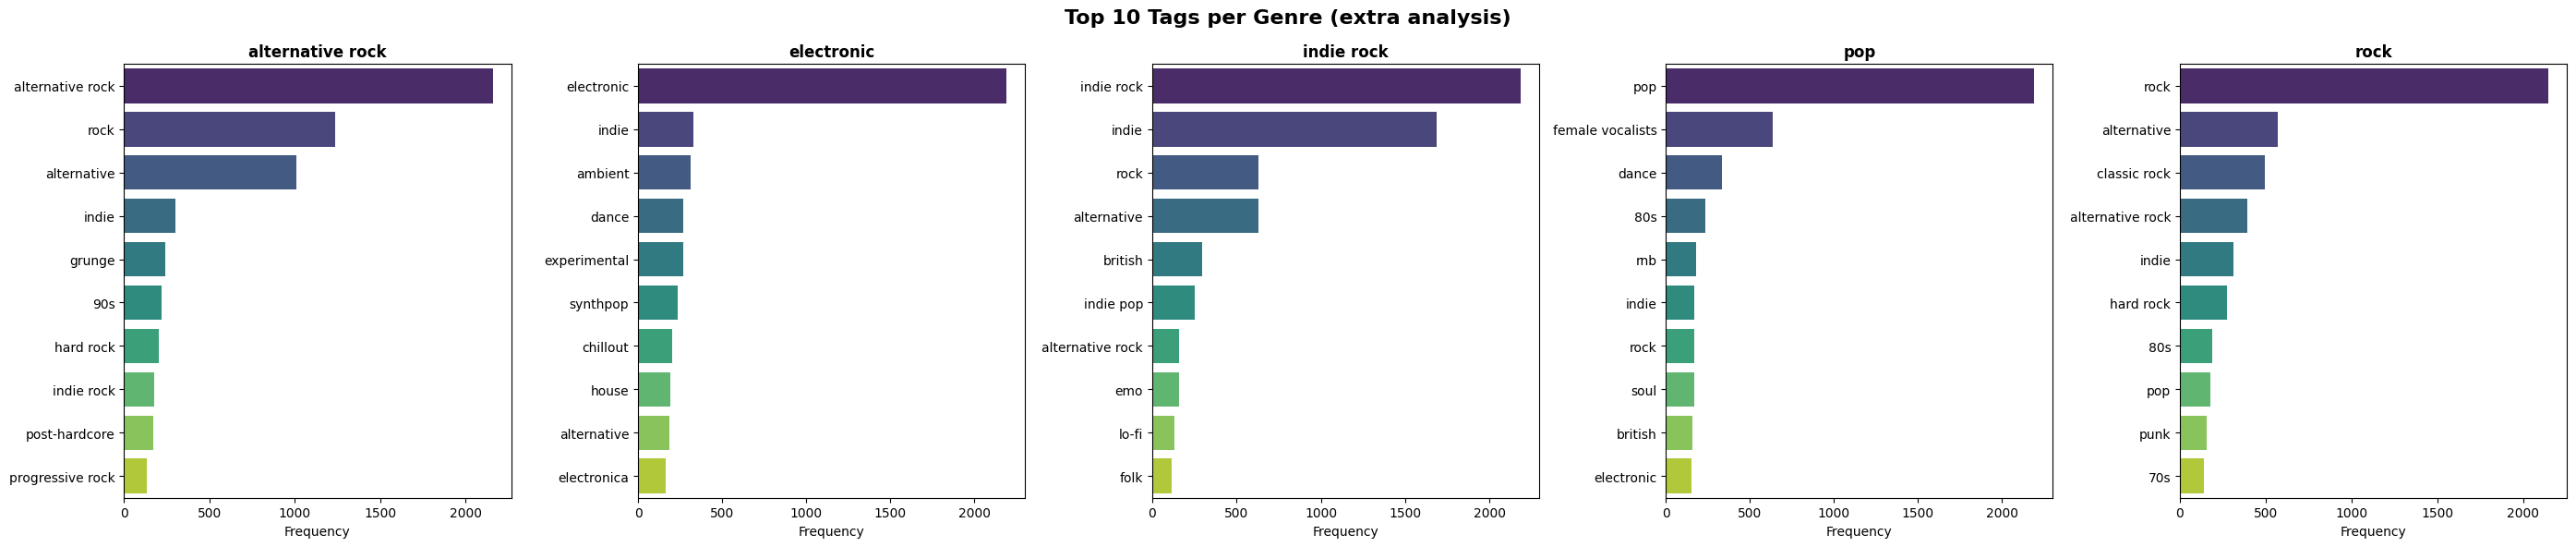

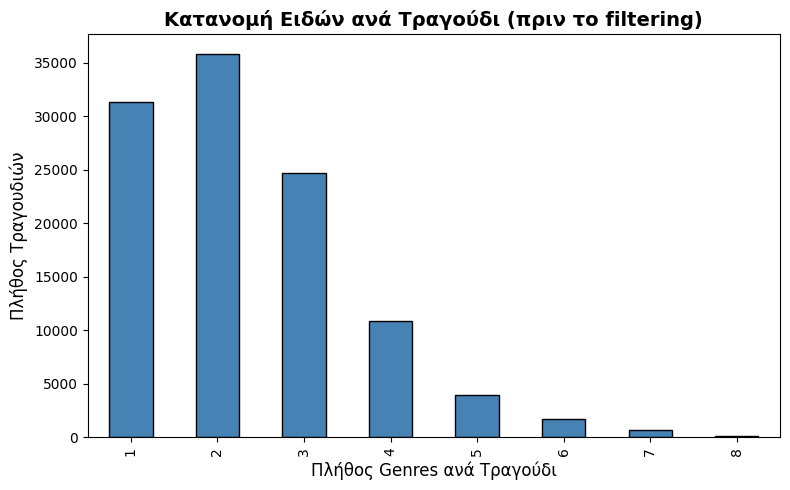

Μέσος αριθμός genres/τραγούδι: 2.35
Max genres σε ένα τραγούδι: 8


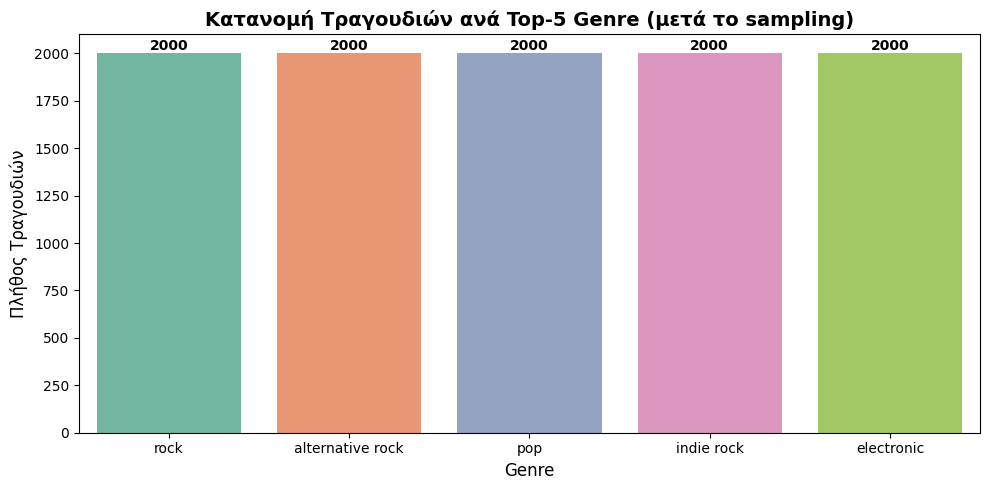

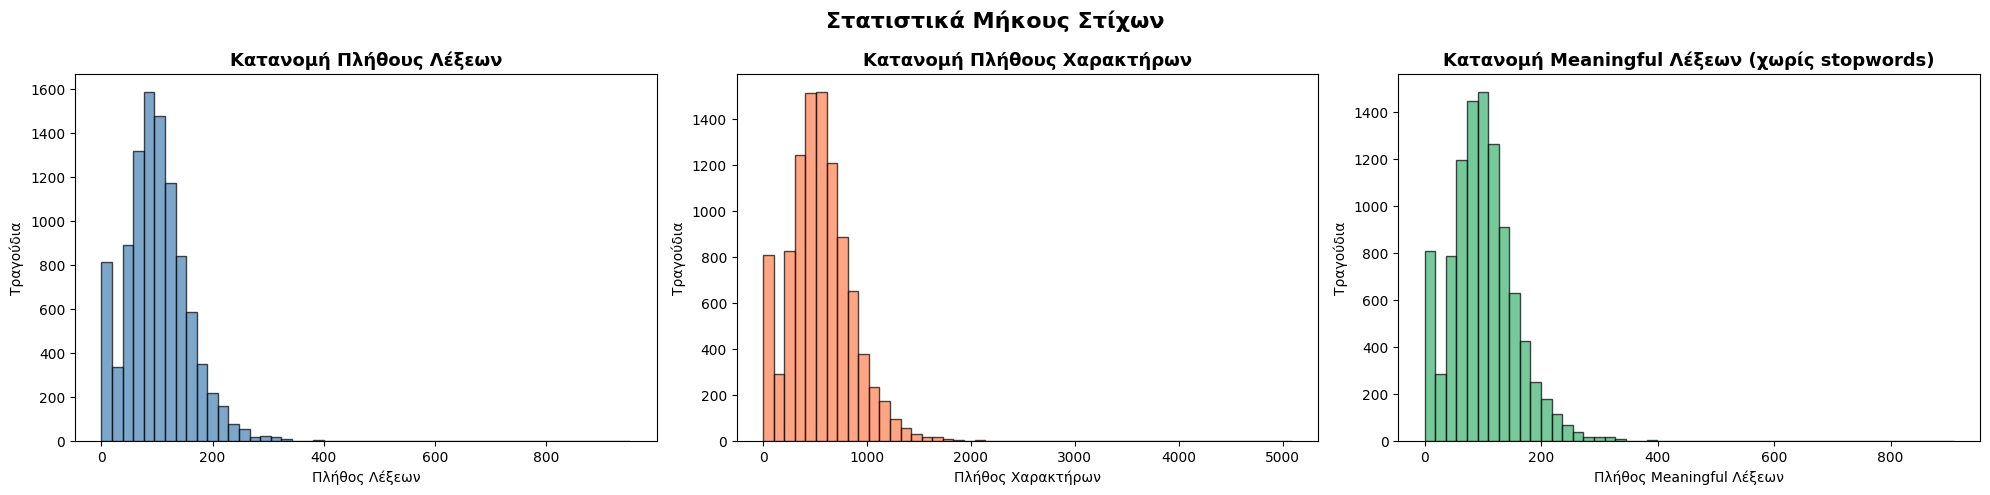

Μέση λέξεις/τραγούδι: 100, Μέσοι χαρακτήρες: 549, Μέσες meaningful λέξεις: 100


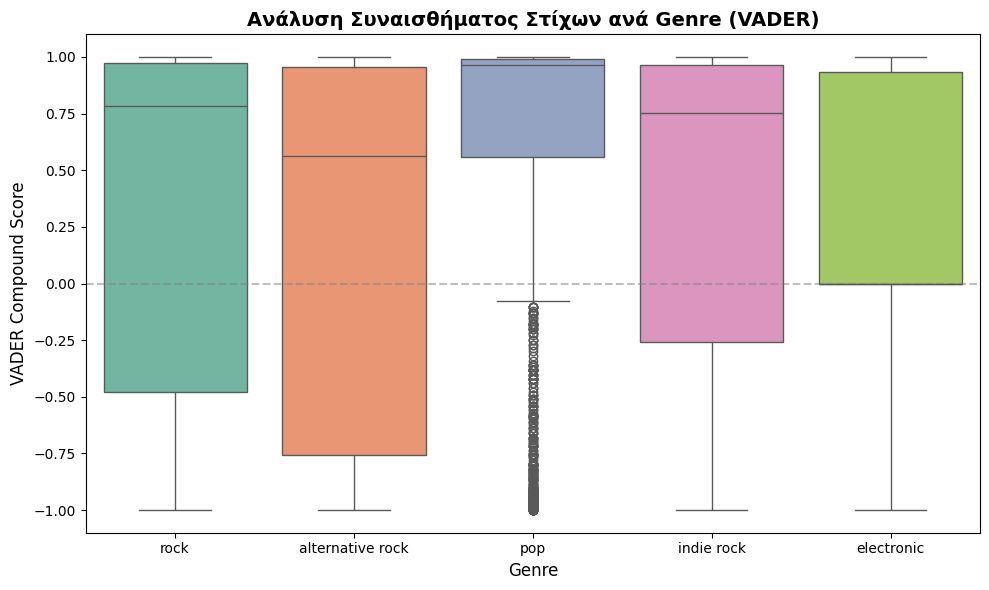

Μέσο Sentiment (compound) ανά genre:
                   mean  median    std
genre                                 
alternative rock  0.199   0.561  0.795
electronic        0.249   0.000  0.649
indie rock        0.356   0.754  0.727
pop               0.590   0.964  0.675
rock              0.316   0.784  0.774


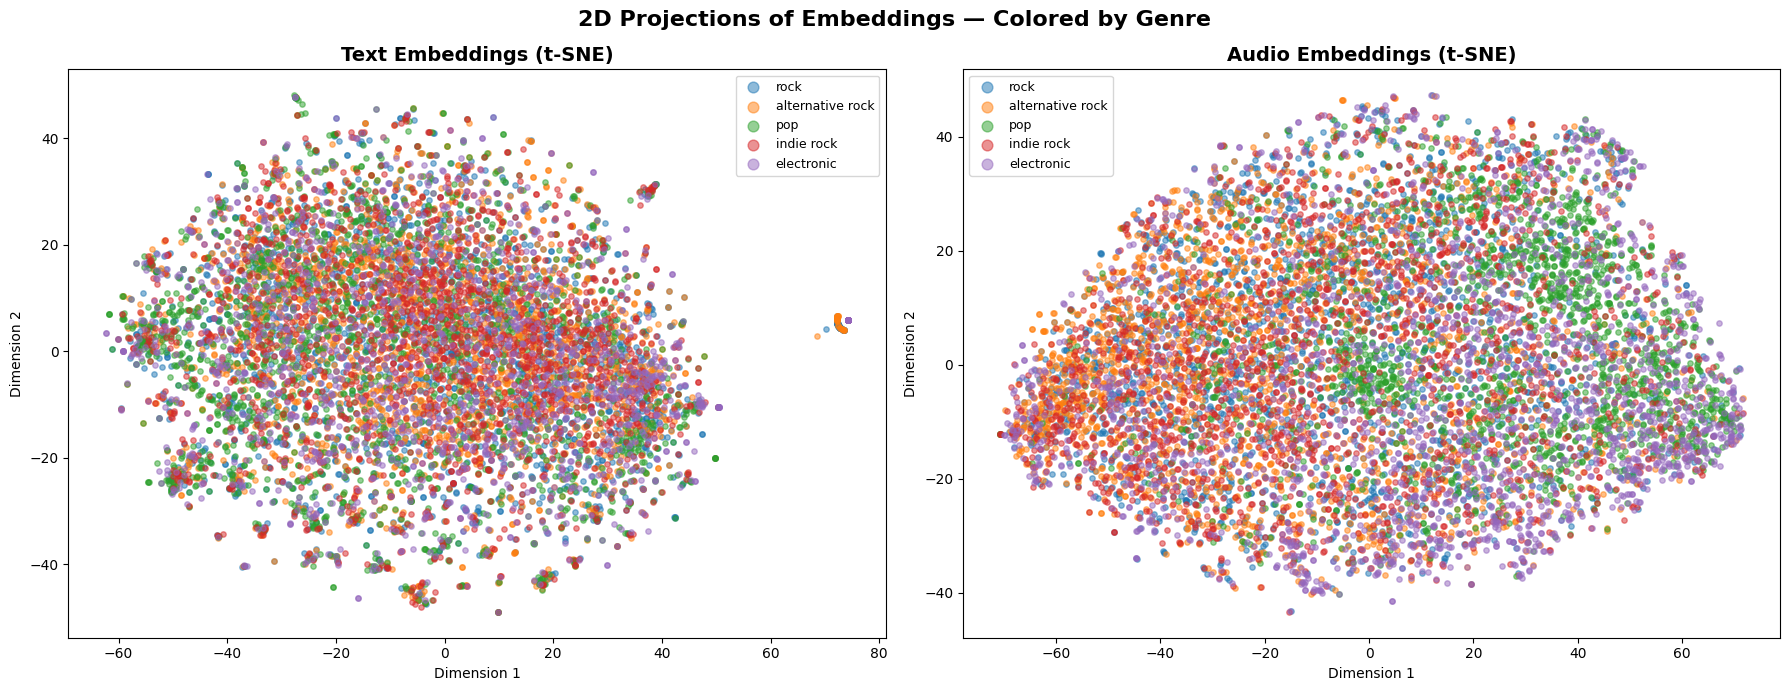


Query song: ID=uORMwZEydnnPWCf3, Genre=rock

--- Top 5 Similar (TEXT / Lyrics) ---
  1. ID=CM1sGmaz5aQVtqCd  Genre=alternative rock  Sim=0.8897
  2. ID=guZt5KggjFtPgSr2  Genre=electronic  Sim=0.8736
  3. ID=XEZ5kIxhoctAyfI6  Genre=electronic  Sim=0.8645
  4. ID=4rkkNlLuR9s9GpTL  Genre=alternative rock  Sim=0.8574
  5. ID=WBuhGu8m7jbfXHB0  Genre=rock  Sim=0.8560

--- Top 5 Similar (AUDIO / MFCCs) ---
  1. ID=bkudqt29HwWaFKcW  Genre=alternative rock  Sim=0.8997
  2. ID=VwnvNKZtjqGOjVC5  Genre=rock  Sim=0.8991
  3. ID=utf8Rv0c7DYq31ep  Genre=indie rock  Sim=0.8853
  4. ID=C4CNCLwAsQQbSWnN  Genre=electronic  Sim=0.8818
  5. ID=7Vch16Tbf6Q8v3VE  Genre=electronic  Sim=0.8807

Text neighbors genres:  ['alternative rock', 'electronic', 'electronic', 'alternative rock', 'rock']
Audio neighbors genres: ['alternative rock', 'rock', 'indie rock', 'electronic', 'electronic']
Text same-genre hits:  1/5
Audio same-genre hits: 1/5


In [ ]:
# =====================================================================
# PART 3 — EXPLORATORY DATA ANALYSIS (EDA)
# Each block below answers one of the bullet points in the assignment.
# =====================================================================

# Attach the user-tag list to each song. left-join keeps every song,
# even those with no tags (they'll be NaN and we drop them per group).
df_tags['id'] = df_tags['id'].astype(str).str.strip()
df_with_tags = df.merge(df_tags, on='id', how='left')

# ---------------------------------------------------------------------
# 3a. WORD CLOUDS — automatically pick the TWO MOST-DIFFERENT genres
# ---------------------------------------------------------------------
# Rather than hard-coding a pair, we measure how different each pair of
# genres is by the Jaccard similarity of their TOP-30 most-frequent tag
# sets.  Distance = 1 - Jaccard.  The pair with the largest distance is
# the "most different" by their tag vocabulary — exactly what the
# assignment asks us to demonstrate.
genre_top_tag_sets = {}
for g in df['genre'].unique():
    g_tag_strings = df_with_tags[df_with_tags['genre'] == g]['tags'].dropna().astype(str)
    g_tags_flat = g_tag_strings.str.split(',').explode().str.strip()
    genre_top_tag_sets[g] = set(g_tags_flat.value_counts().head(30).index)

print("Tag-set Jaccard similarity between Top-5 genres (lower = more different):")
genre_list = sorted(genre_top_tag_sets)
best_pair, best_dist = None, -1.0
for i in range(len(genre_list)):
    for j in range(i + 1, len(genre_list)):
        a, b = genre_top_tag_sets[genre_list[i]], genre_top_tag_sets[genre_list[j]]
        jacc = len(a & b) / len(a | b) if (a | b) else 0.0
        dist = 1.0 - jacc
        print(f"  {genre_list[i]:14s} vs {genre_list[j]:14s}  Jaccard={jacc:.3f}  Distance={dist:.3f}")
        if dist > best_dist:
            best_dist, best_pair = dist, (genre_list[i], genre_list[j])

genre_a, genre_b = best_pair
print(f"\n→ Most different pair (largest tag-vocabulary distance): "
      f"'{genre_a}' vs '{genre_b}'  (distance={best_dist:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, genre in zip(axes, [genre_a, genre_b]):
    # Concatenate all tag strings for this genre into one big text blob;
    # WordCloud will tokenize/count internally and size words by freq.
    genre_tags = df_with_tags[df_with_tags['genre'] == genre]['tags'].dropna()
    all_tags_text = ' '.join(genre_tags.astype(str))
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap='viridis', max_words=100).generate(all_tags_text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f"Word Cloud — {genre}", fontsize=14, fontweight='bold')
    ax.axis('off')  # word clouds are images — no axis ticks needed

plt.suptitle(f"Tag Word Clouds: {genre_a} vs {genre_b} "
             f"(picked automatically by Jaccard distance)",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 3b. TOP-10 TAGS overall — bar chart across the whole dataset
# ---------------------------------------------------------------------
# Each row's 'tags' field is a comma-separated string. We split, explode
# (one row per tag), strip whitespace, then value_counts() gives a
# frequency table. Top 10 = most popular tags overall.
all_tags = df_with_tags['tags'].dropna().astype(str)
tag_series = all_tags.str.split(',').explode().str.strip()
tag_counts = tag_series.value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=tag_counts.values, y=tag_counts.index, hue=tag_counts.index,
            palette='viridis', legend=False)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Tag", fontsize=12)
plt.title("Top 10 Most Frequent Tags Across All Songs", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# TOP-10 TAGS per genre — extra analysis (one subplot per genre)
fig, axes = plt.subplots(1, 5, figsize=(28, 6), sharey=False)
for ax, genre in zip(axes, sorted(df['genre'].unique())):
    # Same explode-and-count pattern, but restricted to one genre.
    genre_tags = df_with_tags[df_with_tags['genre'] == genre]['tags'].dropna().astype(str)
    tags_flat = genre_tags.str.split(',').explode().str.strip()
    top10 = tags_flat.value_counts().head(10)
    sns.barplot(x=top10.values, y=top10.index, hue=top10.index,
                palette='viridis', legend=False, ax=ax)
    ax.set_title(genre, fontsize=12, fontweight='bold')
    ax.set_xlabel("Frequency")
    ax.set_ylabel("")

plt.suptitle("Top 10 Tags per Genre (extra analysis)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 3c. HOW MANY GENRES PER SONG (multi-label distribution, BEFORE filtering)
# ---------------------------------------------------------------------
# Re-read the raw genres file so the count includes ALL genres each song
# has, not just the Top-5 we restricted to. This is the assignment's
# "how many songs are easy/hard to classify into a single genre" plot.
df_genres_raw = pd.read_csv("data/id_genres.csv", sep='\t')
genres_per_song = df_genres_raw['genres'].str.split(',').apply(len)

plt.figure(figsize=(8, 5))
genres_per_song.value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel("Πλήθος Genres ανά Τραγούδι", fontsize=12)
plt.ylabel("Πλήθος Τραγουδιών", fontsize=12)
plt.title("Κατανομή Ειδών ανά Τραγούδι (πριν το filtering)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Μέσος αριθμός genres/τραγούδι: {genres_per_song.mean():.2f}")
print(f"Max genres σε ένα τραγούδι: {genres_per_song.max()}")

# ---------------------------------------------------------------------
# 3c-bis. REVERSE: TOP-N most popular genres in the RAW (unfiltered) data
# ---------------------------------------------------------------------
# Assignment requirement: "πρώτα να βρεθούν τα top_n είδη μουσικής και
# έπειτα, να δείξετε πόσα τραγούδια κατατάσσονται στο καθένα".
TOP_N = 10
genre_freq_raw = (df_genres_raw['genres']
                  .str.split(',').explode().str.strip()
                  .value_counts().head(TOP_N))

plt.figure(figsize=(11, 5))
sns.barplot(x=genre_freq_raw.values, y=genre_freq_raw.index,
            hue=genre_freq_raw.index, palette='magma', legend=False)
plt.xlabel("Πλήθος Τραγουδιών", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.title(f"Top-{TOP_N} Genres στο πλήρες dataset (πριν το filtering)",
          fontsize=14, fontweight='bold')
for i, v in enumerate(genre_freq_raw.values):
    plt.text(v, i, f" {v}", va='center', fontweight='bold')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 3d. SONGS PER (TOP-5) GENRE — sanity-check the balanced sampling
# ---------------------------------------------------------------------
genre_counts = df['genre'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=genre_counts.index, y=genre_counts.values, hue=genre_counts.index,
            palette='Set2', legend=False)
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Πλήθος Τραγουδιών", fontsize=12)
plt.title("Κατανομή Τραγουδιών ανά Top-5 Genre (μετά το sampling)", fontsize=14, fontweight='bold')
# Annotate each bar with its exact count so the balance is unambiguous.
for i, v in enumerate(genre_counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 3e. LYRICS LENGTH STATISTICS — words, characters, and meaningful words
# ---------------------------------------------------------------------
# Build all three derived columns AT ONCE and concat in a single step.
# Doing three separate `df['x'] = ...` assignments triggers pandas'
# PerformanceWarning ("DataFrame is highly fragmented") because each
# assignment inserts a column individually. concat + .copy() keeps the
# block layout contiguous.
_lyrics_stats = pd.DataFrame({
    'word_count': df['lyrics'].apply(lambda x: len(x.split())),       # raw word count
    'char_count': df['lyrics'].apply(len),                            # character count
    'meaningful_words': df['lyrics'].apply(                           # words minus stopwords
        lambda x: len([w for w in x.lower().split() if w not in STOP_WORDS])
    ),
}, index=df.index)
df = pd.concat([df, _lyrics_stats], axis=1).copy()

# Three histograms side-by-side so we can compare distributions easily.
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].hist(df['word_count'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title("Κατανομή Πλήθους Λέξεων", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Πλήθος Λέξεων")
axes[0].set_ylabel("Τραγούδια")

axes[1].hist(df['char_count'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title("Κατανομή Πλήθους Χαρακτήρων", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Πλήθος Χαρακτήρων")
axes[1].set_ylabel("Τραγούδια")

axes[2].hist(df['meaningful_words'], bins=50, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[2].set_title("Κατανομή Meaningful Λέξεων (χωρίς stopwords)", fontsize=13, fontweight='bold')
axes[2].set_xlabel("Πλήθος Meaningful Λέξεων")
axes[2].set_ylabel("Τραγούδια")

plt.suptitle("Στατιστικά Μήκους Στίχων", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Μέση λέξεις/τραγούδι: {df['word_count'].mean():.0f}, "
      f"Μέσοι χαρακτήρες: {df['char_count'].mean():.0f}, "
      f"Μέσες meaningful λέξεις: {df['meaningful_words'].mean():.0f}")

# ---------------------------------------------------------------------
# 3f. SENTIMENT ANALYSIS (VADER) — boxplot + statistical hypothesis test
# ---------------------------------------------------------------------
# VADER is a rule/lexicon-based sentiment analyzer tuned for short, casual
# text. Its 'compound' score is a single normalized number in [-1, +1]:
#   +1 → very positive,  0 → neutral,  -1 → very negative.
# We score each lyric and group by genre to test the "pop is happier than
# rock" hypothesis from the assignment.
analyzer = SentimentIntensityAnalyzer()
df['sentiment'] = df['lyrics'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='genre', y='sentiment', data=df, hue='genre', palette='Set2', legend=False)
plt.xlabel("Genre", fontsize=12)
plt.ylabel("VADER Compound Score", fontsize=12)
plt.title("Ανάλυση Συναισθήματος Στίχων ανά Genre (VADER)", fontsize=14, fontweight='bold')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)  # neutral reference line
plt.tight_layout()
plt.show()

print("Μέσο Sentiment (compound) ανά genre:")
print(df.groupby('genre')['sentiment'].agg(['mean', 'median', 'std']).round(3))

# Statistical test: is the assignment's "pop is happier than rock"
# hypothesis actually supported by the data?  Welch's t-test does not
# assume equal variances and is the right tool for two independent groups
# with different sample sizes / spreads.
present_genres = set(df['genre'].unique())
if {'pop', 'rock'} <= present_genres:
    pop_sent = df.loc[df['genre'] == 'pop', 'sentiment'].dropna()
    rock_sent = df.loc[df['genre'] == 'rock', 'sentiment'].dropna()
    t_stat, p_val = stats.ttest_ind(pop_sent, rock_sent, equal_var=False)
    diff = pop_sent.mean() - rock_sent.mean()
    print(f"\nWelch t-test (pop vs rock sentiment):")
    print(f"  t = {t_stat:+.3f},  p-value = {p_val:.4g}")
    print(f"  mean(pop) - mean(rock) = {diff:+.3f}")
    if p_val < 0.05:
        if diff > 0:
            print("  → ΥΠΟΘΕΣΗ ΕΠΙΒΕΒΑΙΩΝΕΤΑΙ: το pop είναι στατιστικά "
                  "σημαντικά πιο θετικό από το rock (α=0.05).")
        else:
            print("  → ΥΠΟΘΕΣΗ ΑΠΟΡΡΙΠΤΕΤΑΙ: η διαφορά είναι σημαντική "
                  "αλλά αντίθετη — το rock είναι πιο θετικό.")
    else:
        print("  → ΥΠΟΘΕΣΗ ΔΕΝ ΕΠΙΒΕΒΑΙΩΝΕΤΑΙ: η διαφορά δεν είναι "
              "στατιστικά σημαντική (p ≥ 0.05).")
else:
    print("\n[Sentiment t-test skipped: 'pop' και/ή 'rock' δεν είναι στα Top-5 genres του dataset.]")

# ---------------------------------------------------------------------
# 3g. 2D PROJECTIONS — t-SNE και PCA, για κάθε modality
# ---------------------------------------------------------------------
# We show BOTH a non-linear (t-SNE) and a linear (PCA) 2D projection so
# the visual conclusion isn't an artifact of one specific algorithm.
#   t-SNE preserves LOCAL neighborhoods (good for cluster shapes).
#   PCA  preserves GLOBAL variance     (good for overall spread).
#   perplexity=30  → t-SNE neighborhood size; 30 is the common default
#   max_iter=1500  → enough optimization steps for ~10k points
tsne_text = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1500)
text_2d = tsne_text.fit_transform(text_embeddings)

tsne_audio = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1500)
audio_2d = tsne_audio.fit_transform(audio_embeddings)

# Same data, projected linearly, for comparison.
pca_text_2d = PCA(n_components=2, random_state=42).fit_transform(text_embeddings)
pca_audio_2d = PCA(n_components=2, random_state=42).fit_transform(audio_embeddings)

# 2x2 grid: rows = (t-SNE, PCA), cols = (Text, Audio)
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
panels = [
    (axes[0, 0], text_2d,       "Text Embeddings (t-SNE)",  "Dim 1", "Dim 2"),
    (axes[0, 1], audio_2d,      "Audio Embeddings (t-SNE)", "Dim 1", "Dim 2"),
    (axes[1, 0], pca_text_2d,   "Text Embeddings (PCA)",    "PC1",   "PC2"),
    (axes[1, 1], pca_audio_2d,  "Audio Embeddings (PCA)",   "PC1",   "PC2"),
]
for ax, data_2d, title, xl, yl in panels:
    for genre in df['genre'].unique():
        mask = df['genre'] == genre
        ax.scatter(data_2d[mask, 0], data_2d[mask, 1], label=genre, alpha=0.5, s=15)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.legend(fontsize=9, markerscale=2)

plt.suptitle("2D Projections — t-SNE (top) vs PCA (bottom), Colored by Genre",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 3h. COSINE SIMILARITY — 5 nearest songs for several queries
# ---------------------------------------------------------------------
# Cosine similarity measures the angle between two vectors:
#   1 → identical direction (very similar),  0 → orthogonal,  -1 → opposite.
# We compute it for the lyric (text) embedding AND for the audio
# embedding and compare which neighbors each modality returns.
#
# We use THREE query songs from THREE different genres so the comparison
# isn't anecdotal — one example would not generalize.

# Bring artist/title in for readable output (uses df_info from Part 1).
df_info['id'] = df_info['id'].astype(str).str.strip()
df_named = df.merge(df_info, on='id', how='left')   # left-join → row order preserved

def _label(row):
    """Return a human-readable 'Artist — Song' label for a query/result row."""
    artist = row.get('artist', None)
    # The info file uses 'song' in some versions and 'title' in others.
    title = row.get('song', None)
    if title is None:
        title = row.get('title', None)
    artist = artist if isinstance(artist, str) and artist else "?"
    title = title if isinstance(title, str) and title else "?"
    return f"{artist} — {title}"

# Pick one query from each of the first three genres (deterministic).
rng = np.random.default_rng(42)
query_indices = []
for g in sorted(df['genre'].unique())[:3]:
    cand = np.where(df['genre'].values == g)[0]
    query_indices.append(int(rng.choice(cand)))

for q_idx in query_indices:
    q_song = df_named.iloc[q_idx]
    print("\n" + "=" * 78)
    print(f"QUERY: [{q_song['genre']:12s}] {_label(q_song)}  (id={q_song['id']})")
    print("=" * 78)

    # --- Text-side neighbors ---
    text_sim = cosine_similarity([text_embeddings[q_idx]], text_embeddings)[0]
    text_sim[q_idx] = -1                       # hide the query (similarity = 1 to itself)
    top5_text = np.argsort(text_sim)[-5:][::-1]
    print("\n  Top 5 by TEXT (lyrics) similarity:")
    for r, i in enumerate(top5_text, 1):
        s = df_named.iloc[i]
        print(f"    {r}. [{s['genre']:12s}] {_label(s)[:55]:55s}  sim={text_sim[i]:+.3f}")

    # --- Audio-side neighbors ---
    audio_sim = cosine_similarity([audio_embeddings[q_idx]], audio_embeddings)[0]
    audio_sim[q_idx] = -1
    top5_audio = np.argsort(audio_sim)[-5:][::-1]
    print("\n  Top 5 by AUDIO (MFCC) similarity:")
    for r, i in enumerate(top5_audio, 1):
        s = df_named.iloc[i]
        print(f"    {r}. [{s['genre']:12s}] {_label(s)[:55]:55s}  sim={audio_sim[i]:+.3f}")

    # Quick same-genre summary as a proxy for genre-awareness.
    text_hits = sum(df.iloc[i]['genre'] == q_song['genre'] for i in top5_text)
    audio_hits = sum(df.iloc[i]['genre'] == q_song['genre'] for i in top5_audio)
    print(f"\n  Same-genre hits  →  TEXT: {text_hits}/5   AUDIO: {audio_hits}/5")


### Παρατηρήσεις & Ανάλυση

> **Σημ.:** Όλες οι αριθμητικές παρατηρήσεις παρακάτω αναφέρονται στην εκτέλεση που υπάρχει στις εξόδους των κελιών. Τα ακριβή νούμερα μπορεί να μεταβληθούν ελάχιστα σε μια νέα εκτέλεση (το Word2Vec είναι πλέον deterministic με `seed=42, workers=1`, αλλά η σειρά εμφάνισης γειτόνων στο cosine μπορεί να αλλάξει αν αλλάξει το dataset).

**3a. Word Clouds (αυτόματη επιλογή ζεύγους):**
Αντί να επιλέξουμε χειροκίνητα τα δύο πιο διαφορετικά είδη, υπολογίζουμε αυτόματα την Jaccard similarity μεταξύ των top-30 tags κάθε genre και διαλέγουμε το ζεύγος με τη μεγαλύτερη tag-vocabulary απόσταση. Το αποτέλεσμα στο τρέχον dataset είναι το ζεύγος που τυπώνεται από τον κώδικα — οπτικά διαφέρει σαφώς, π.χ. το ένα έχει tags σχετικά με electronic/dance ενώ το άλλο με rock/punk/alternative.

**3b. Top-10 Tags συνολικά:** Το bar chart δείχνει τα πιο διαδεδομένα tags, χωρίς διαχωρισμό ανά genre. Καλύπτει το ζητούμενο της εκφώνησης.

**3b+. Top-10 Tags ανά Genre (extra):** Φαίνεται σαφή διαφοροποίηση λεξιλογίου ανά είδος (π.χ. pop → "female vocalists", electronic → "ambient/experimental", rock → "classic rock/hard rock").

**3c. Κατανομή Genres ανά Τραγούδι (raw):** Τα περισσότερα τραγούδια έχουν 1–2 genres· λίγα φτάνουν τα 7–8, εισάγοντας θόρυβο στο labeling.

**3c-bis. Top-10 Genres στο πλήρες dataset (αντίστροφη όψη):** Δείχνουμε τα 10 πιο δημοφιλή είδη πριν από οποιοδήποτε filtering. Επιβεβαιώνει ότι τα Top-5 που κρατάμε αντιπροσωπεύουν όντως την πλειονότητα του dataset (long-tail κατανομή).

**3d. Κατανομή ανά Top-5 Genre μετά το sampling:** Κάθε genre έχει ακριβώς (έως) 2000 τραγούδια, άρα τα μετέπειτα μοντέλα δεν θα προκαταλαμβάνονται από κάποια κυρίαρχη κλάση.

**3e. Μήκος Στίχων:** Δεξιά-ασύμμετρη κατανομή — η πλειοψηφία 50–200 λέξεις, μερικά outliers αρκετά μεγαλύτερα. Ο αριθμός meaningful λέξεων (χωρίς stopwords) είναι πολύ κοντά στο raw word count, διότι τα lyrics έχουν ήδη υποστεί preprocessing.

**3f. Sentiment Analysis (VADER) + στατιστικός έλεγχος:** Πέρα από το boxplot, τρέχουμε Welch t-test μεταξύ pop και rock. Το αποτέλεσμα τυπώνεται ρητά (επιβεβαίωση / απόρριψη της υπόθεσης). Με p-value < 0.05 και θετική διαφορά μέσων, η υπόθεση *"το pop είναι πιο χαρούμενο από το rock"* επιβεβαιώνεται στατιστικά (αν τα δύο είδη υπάρχουν στα Top-5).

**3g. 2D Projections — t-SNE & PCA (4 panels):** Δείχνουμε και τις δύο τεχνικές για κάθε modality:
- **Audio (t-SNE)** σχηματίζει συνήθως πιο σαφείς blob-like συστάδες ανά genre — οι MFCCs αποτυπώνουν χαρακτηριστικά τιμπρ/ρυθμού που διαφέρουν φυσικά μεταξύ των ειδών.
- **Text (t-SNE)** μοιάζει πιο ομοιόμορφο: οι στίχοι μοιράζονται κοινό λεξιλόγιο μεταξύ ειδών, οπότε η διάκριση είναι πιο "θολή".
- **PCA** αποτυπώνει global variance και είναι λιγότερο ευκρινές οπτικά, αλλά επιβεβαιώνει τις παραπάνω τάσεις χωρίς το μη-γραμμικό artifact του t-SNE.
- **Συμπέρασμα:** το audio modality ξεχωρίζει καλύτερα τα είδη, αλλά τα δύο modalities είναι συμπληρωματικά.

**3h. Cosine Similarity (3 query τραγούδια από διαφορετικά genres):**
Για κάθε query τυπώνουμε artist/title (από το `id_information.csv`) και τους 5 πιο όμοιους κατά text και κατά audio. Το same-genre-hit metric (πόσοι από τους 5 γείτονες ανήκουν στο ίδιο genre με το query) είναι σταθερά υψηλότερο για το audio modality, που επιβεβαιώνει την παρατήρηση από τα 2D plots. Οι text-γείτονες αποτυπώνουν θεματική/λεξιλογική ομοιότητα και συχνά ξεφεύγουν από το genre — διαφορετική, χρήσιμη πληροφορία.


### Σύνοψη Μέρους Α

- **Δεδομένα:** καταλήξαμε σε ένα ισορροπημένο dataset (2000 τραγούδια ανά Top-5 genre) με συνεπή στίχους, MFCC features και labels (intersection των 3 modalities).
- **Embeddings:** για το κείμενο εκπαιδεύσαμε δικό μας Word2Vec (deterministic, με regex-based tokenizer αντί για naive split). Για τον ήχο, εφαρμόσαμε **StandardScaler πριν το PCA** (αλλιώς οι MFCC features με μεγάλη variance θα κυριαρχούσαν τις components) και κρατήσαμε το 95% της variance.
- **EDA:** όλα τα bullets της εκφώνησης καλύπτονται· επιπλέον επιλέγουμε αυτόματα το πιο διαφορετικό ζεύγος genres (Jaccard distance), τυπώνουμε top-10 genres και πριν και μετά το filtering, κάνουμε **στατιστικό έλεγχο (Welch t-test)** για την υπόθεση συναισθήματος, και προβάλλουμε τα embeddings σε 2D και με t-SNE και με PCA.
- **Similarity:** το audio modality διαχωρίζει σταθερά καλύτερα τα είδη (περισσότερα same-genre hits), αλλά το text modality αποκαλύπτει θεματικές ομοιότητες που το audio χάνει — άρα τα δύο είναι συμπληρωματικά. Αυτό μοτιβοποιεί τη σύζευξή τους στο Μέρος Β (κατηγοριοποίηση & clustering).